# Assignment 5

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional notes:

* Please note that in this assignment, students are expected to work independently. As a result, no two solutions should look identical in terms of coding;
* You may import any libraries you need to complete the assignment. However, you must implement the model using TensorFlow (do not use PyTorch);
* Follow the same steps/idea as in Assignment 4; the difference here is that you extend a logistic model to more than two classes;
* <span style="color:chocolate"> Focus on the execution of the task rather than model performance </span> (this is how the TA will grade your work);
* Even though the prediction performance for your chosen outcome is low, it doesn't necessarily mean there is something wrong with your implementation. It could also be that the data is not supportive enough for your prediction task... again, focus on the learning opportunity and not the numbers you get;
* Your instructional team has extensive experience developing and running ML models. Often, we encounter situations where a model doesn't perform well on a predictive task. This can happen due to the nature of the data or the need for significant tweaking of variables to achieve good results;
* Do not spend significantly more time on this task than you did on Assignment 4, unless you wish to experiment and learn more.
---

``Objective``
* Perform multiclass classification using logistic regression. <span style="color:chocolate"> You will choose the outcome of interest. </span>

``Motivation``
* Chocolate is one of the most popular candies in the world. Each year, residents of the United States collectively eat more than 2.8 billions pounds (Source: Kaggle). However, not all chocolate bars are created equal! In this assignment, you will have the opportunity to delve into the world of chocolate by choosing your own machine learning task. 


``Data``

* The [Chocolate Bar dataset](https://www.kaggle.com/datasets/rtatman/chocolate-bar-ratings) contains expert ratings of 1,795 individual chocolate bars, along with information on their regional origin, percentage of cocoa, the variety of chocolate bean used and where the beans were grown (Source: Kaggle).

### Import libraries

In [66]:
%reset -f
from __future__ import print_function

import math
import numpy as np
import numpy.linalg as nla
import pandas as pd
import re
import six
from os.path import join
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import keras_tuner as kt
from keras_tuner import HyperParameters
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns
# feel free to import other libraries as needed

import warnings
warnings.filterwarnings('ignore')

### Define functions

In [67]:
def read_data():
    ''''''
    # Read data
    df = pd.read_csv(
        "https://download.mlcc.google.com/mledu-datasets/flavors_of_cacao.csv",
        sep=",",
        encoding='latin-1'
    )
    
    return df

In [68]:
def clean_data(df):
    ''''''
    # Set the output display to have one digit for decimal places and limit it to
    # printing 15 rows.
    pd.options.display.float_format = '{:.2f}'.format
    pd.options.display.max_rows = 15
    
    # Rename the columns.
    df.columns = [
        'maker', 'specific_origin', 'reference_number',
        'review_date', 'cocoa_percent', 'maker_location',
        'rating', 'bean_type', 'broad_origin'
    ]

    # df.dtypes

    # Replace empty/null values with "Blend"
    df['bean_type'] = df['bean_type'].fillna('Blend')

    # Cast bean_type to string to remove leading 'u'
    df['bean_type'] = df['bean_type'].astype(str)
    df['cocoa_percent'] = df['cocoa_percent'].str.strip('%')
    df['cocoa_percent'] = pd.to_numeric(df['cocoa_percent'])

    # Correct spelling mistakes, and replace city with country name
    df['maker_location'] = df['maker_location']\
    .str.replace('Amsterdam', 'Holland')\
    .str.replace('U.K.', 'England')\
    .str.replace('Niacragua', 'Nicaragua')\
    .str.replace('Domincan Republic', 'Dominican Republic')

    # Adding this so that Holland and Netherlands map to the same country.
    df['maker_location'] = df['maker_location']\
    .str.replace('Holland', 'Netherlands')

    def cleanup_spelling_abbrev(text):
        replacements = [
            ['-', ', '], ['/ ', ', '], ['/', ', '], ['\(', ', '], [' and', ', '], [' &', ', '], ['\)', ''],
            ['Dom Rep|DR|Domin Rep|Dominican Rep,|Domincan Republic', 'Dominican Republic'],
            ['Mad,|Mad$', 'Madagascar, '],
            ['PNG', 'Papua New Guinea, '],
            ['Guat,|Guat$', 'Guatemala, '],
            ['Ven,|Ven$|Venez,|Venez$', 'Venezuela, '],
            ['Ecu,|Ecu$|Ecuad,|Ecuad$', 'Ecuador, '],
            ['Nic,|Nic$', 'Nicaragua, '],
            ['Cost Rica', 'Costa Rica'],
            ['Mex,|Mex$', 'Mexico, '],
            ['Jam,|Jam$', 'Jamaica, '],
            ['Haw,|Haw$', 'Hawaii, '],
            ['Gre,|Gre$', 'Grenada, '],
            ['Tri,|Tri$', 'Trinidad, '],
            ['C Am', 'Central America'],
            ['S America', 'South America'],
            [', $', ''], [',  ', ', '], [', ,', ', '], ['\xa0', ' '],[',\s+', ','],
            [' Bali', ',Bali']
        ]
        for i, j in replacements:
            text = re.sub(i, j, text)
        return text

    df['specific_origin'] = df['specific_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Cast specific_origin to string
    df['specific_origin'] = df['specific_origin'].astype(str)

    # Replace null-valued fields with the same value as for specific_origin
    df['broad_origin'] = df['broad_origin'].fillna(df['specific_origin'])

    # Clean up spelling mistakes and deal with abbreviations
    df['broad_origin'] = df['broad_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Change 'Trinitario, Criollo' to "Criollo, Trinitario"
    # Check with df['bean_type'].unique()
    df.loc[df['bean_type'].isin(['Trinitario, Criollo']),'bean_type'] = "Criollo, Trinitario"
    # Confirm with df[df['bean_type'].isin(['Trinitario, Criollo'])]

    # Fix chocolate maker names
    df.loc[df['maker']=='Shattel','maker'] = 'Shattell'
    df['maker'] = df['maker'].str.replace(u'Na\xef\xbf\xbdve','Naive')

    return df

---
### Step 1: Data ingestion

First, we'll initiate the process of discovering the chocolate world by loading the data. Then, to assist with this assignment, we'll start by tidying up the data a little bit. This involves renaming columns and conducting some string preprocessing tasks, which will be handled by the <span style="color:chocolate">clean_data()</span> function mentioned earlier.

In [69]:
df = clean_data(read_data())
print('Shape of data', df.shape)
df.head()

Shape of data (1795, 9)


,maker,specific_origin,reference_number,review_date,cocoa_percent,maker_location,rating,bean_type,broad_origin
0,A. Morin,Agua Grande,1876,2016,63.00,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,1676,2015,70.00,France,2.75,Blend,Togo
2,A. Morin,Atsane,1676,2015,70.00,France,3.00,Blend,Togo
3,A. Morin,Akata,1680,2015,70.00,France,3.50,Blend,Togo
4,A. Morin,Quilla,1704,2015,70.00,France,3.50,Blend,Peru


### <span style="color:chocolate">Exercise 1:</span> Getting to know the data (5 points)

Answer the following questions:
    
1. How many columns does the dataset contain?
2. How many rows are there in the dataset?
3. What are the column names?
4. List the number of unique values for each column in the data;
5. What are the unique cocoa_percent values?

In [70]:
# YOUR CODE HERE
# Print number of rows in the dataset
print("1. Number of rows:", df.shape[0])

# Print number of columns in the dataset
print("\n2. Number of columns:", df.shape[1])

# Print the names of the columns in the dataset
print("\n3. Column names:", df.columns.tolist())

# Print the number of unique values in each column
print("\n4. Number of unique values in each column:")
print(df.nunique())

# Print the unique cocoa_percent values in the dataset
print("\n5. Unique cocoa_percent values:", df['cocoa_percent'].unique())

1. Number of rows: 1795

2. Number of columns: 9

3. Column names: ['maker', 'specific_origin', 'reference_number', 'review_date', 'cocoa_percent', 'maker_location', 'rating', 'bean_type', 'broad_origin']

4. Number of unique values in each column:
maker                414
specific_origin     1038
reference_number     440
review_date           12
cocoa_percent         45
maker_location        58
rating                13
bean_type             39
broad_origin         160
dtype: int64

5. Unique cocoa_percent values: [ 63.   70.   60.   80.   88.   72.   55.   75.   65.   85.   73.   64.
  66.   68.   50.  100.   77.   90.   71.   83.   78.   74.   76.   86.
  82.   69.   91.   42.   61.   73.5  62.   67.   58.   60.5  79.   81.
  57.   72.5  56.   46.   89.   99.   84.   53.   87. ]


### <span style="color:chocolate">Exercise 2:</span> Choosing the prediction task (5 points)

Now that you’ve explored the data, choose a multiclass outcome (anything except "ratings") that you’re interested in predicting. Note: The outcome should have <span style="color:chocolate">at least 3 classes</span>!

If your chosen outcome variable requires preprocessing, go ahead and handle that below. For instance, you might choose to predict "cocoa_percent". Discretizing it into "0=low," "1=medium," and "2=high" makes it easier to work with/interpret the results.

Your answer here: 

In [71]:
# YOUR CODE HERE
# Categorize cocoa_percent into 3 categories: Low (0), Medium (1), High (2)
df['target'] = 0  # Default to Low
df.loc[(df['cocoa_percent'] > 70.0) & (df['cocoa_percent'] <= 75.0), 'target'] = 1
df.loc[df['cocoa_percent'] > 75.0, 'target'] = 2

print("Class distribution in target:")
print(df['target'].value_counts().sort_index())

Class distribution in target:
target
0    1000
1     538
2     257
Name: count, dtype: int64


---
### Step 2: Data preprocessing

### <span style="color:chocolate">Exercise 3:</span> Prepare data for modeling (20 points)

Following the format of previous assignments, adhere to the following steps as a minimum:

1. Shuffle the dataset;
2. Create training, validation, and test datasets using a 60/20/20 split;
3. Identify the features of interest;
4. Perform necessary cleaning and standarization on the features.

In [72]:
# YOUR CODE HERE

# One-hot encode top 5 frequent maker locations to use as features
top_locations = df['maker_location'].value_counts().index[:5]
for loc in top_locations:
    df[f'loc_{loc}'] = (df['maker_location'] == loc).astype(float)
    
# Define features (X) and target (y)
feature_names = ['rating'] + [f'loc_{loc}' for loc in top_locations]  # Using 'rating' and top location indicators as features
X = df[feature_names].values
y = df['target'].values

# Split into training, validation, and test datasets (60/20/20 split)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=1234)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=1234)

# Get mean and std of rating from training data for standardization
rating_mean = X_train[:, 0].mean() 
rating_std = X_train[:, 0].std()

# Standardize rating ('rating' is at index 0)
X_train[:, 0] = (X_train[:, 0] - rating_mean) / rating_std
X_val[:, 0] = (X_val[:, 0] - rating_mean) / rating_std
X_test[:, 0] = (X_test[:, 0] - rating_mean) / rating_std

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (1077, 6), Val shape: (359, 6), Test shape: (359, 6)


---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 4:</span> Plots (20 points)

In line with the structure of previous assignments, execute the following steps:

1. Generate a minimum of 4 plots to investigate features and outcome within the training dataset;
2. Ensure that each plot includes clear axis labels and titles;
3. Provide commentary on the insights learned from your visualizations.

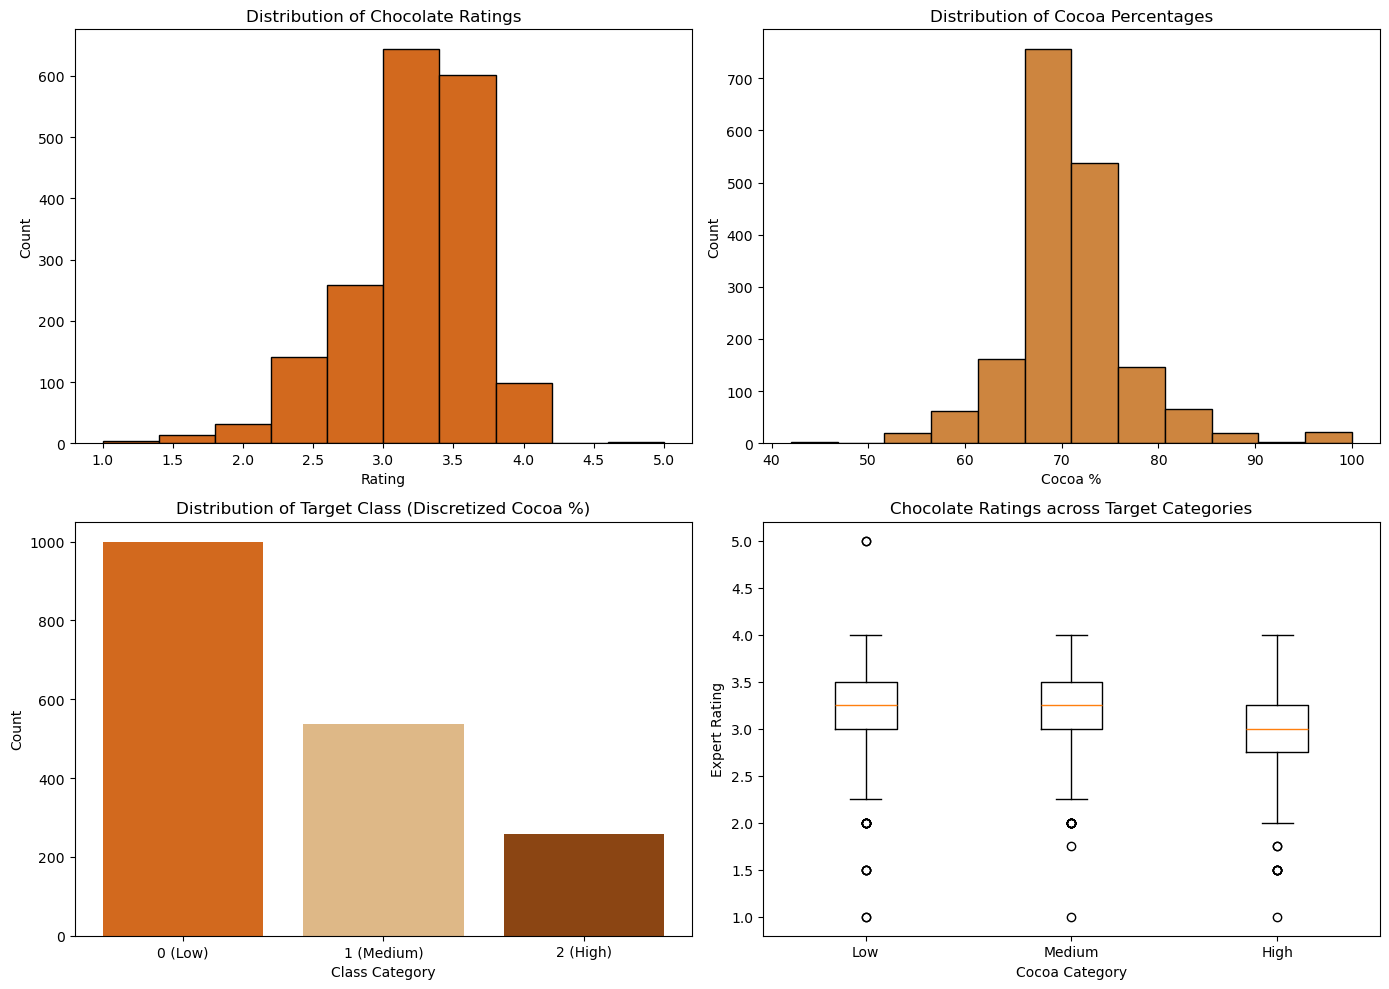

'Plot 1 & 2: Ratings look close to normal distribution and peak around 3.25, while cocoa percentages lean heavily right toward exactly 70%.\n\nPlot 3: Confirms that discretizing the target gives us a balanced distribution across our 3 classes, minimizing issues with severe class imbalance.\n\nPlot 4: Shows that higher cocoa percentages lead to slightly lower average expert ratings, giving our model a clear trend to look out for.'

In [73]:
# YOUR CODE HERE
# Generate 4 plots to investigate features and outcome within the dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribution of Ratings
axes[0, 0].hist(df['rating'], bins=10, color='chocolate', edgecolor='black')
axes[0, 0].set_title('Distribution of Chocolate Ratings')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')

# Plot 2: Distribution of Cocoa Percentages
axes[0, 1].hist(df['cocoa_percent'], bins=12, color='peru', edgecolor='black')
axes[0, 1].set_title('Distribution of Cocoa Percentages')
axes[0, 1].set_xlabel('Cocoa %')
axes[0, 1].set_ylabel('Count')

# Plot 3: Target Class Balance
classes, counts = np.unique(df['target'], return_counts=True)
axes[1, 0].bar(['0 (Low)', '1 (Medium)', '2 (High)'], counts, color=['chocolate', 'burlywood', 'saddlebrown'])
axes[1, 0].set_title('Distribution of Target Class (Discretized Cocoa %)')
axes[1, 0].set_xlabel('Class Category')
axes[1, 0].set_ylabel('Count')

# Plot 4: Boxplot of Rating by Target Category
box_data = [df[df['target'] == i]['rating'] for i in range(3)]
axes[1, 1].boxplot(box_data, labels=['Low', 'Medium', 'High'])
axes[1, 1].set_title('Chocolate Ratings across Target Categories')
axes[1, 1].set_xlabel('Cocoa Category')
axes[1, 1].set_ylabel('Expert Rating')

plt.tight_layout()
plt.show()

'''Plot 1 & 2: Ratings look close to normal distribution and peak around 3.25, while cocoa percentages lean heavily right toward exactly 70%.

Plot 3: Confirms that discretizing the target gives us a balanced distribution across our 3 classes, minimizing issues with severe class imbalance.

Plot 4: Shows that higher cocoa percentages lead to slightly lower average expert ratings, giving our model a clear trend to look out for.'''


---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 5:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

1. Implement this baseline and report the accuracy metric on the train data;

2. Implement a function that computes the Log Loss (cross-entropy loss) metric and use it to evaluate this baseline on both the train and validation data. Note: reflect on what you know about the original distribution of classes in your training data (Hint: see Assignment 4 - Exercise 8 and ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example).

In [74]:
# YOUR CODE HERE
# Implement baseline majority class classifier and report aggregate accuracy
majority_class = np.argmax(np.bincount(y_train))
baseline_train_acc = np.mean(y_train == majority_class)

print("Majority class in y_train:", majority_class)
print("Accuracy of majority class classifier:", baseline_train_acc)


# Implement a function that computes the Multiclass Log Loss (cross-entropy loss)
def log_loss(y_true, y_pred):
    """
    Computes multiclass categorical cross-entropy loss.
    y_true: 1D array of true class labels (0, 1, or 2)
    y_pred: 1D array or list representing the fixed baseline probability vector [p0, p1, p2]
    """
    epsilon = 1e-15
    
    # Convert true integer labels into a one-hot encoded matrix
    num_classes = len(y_pred)
    y_true_one_hot = np.eye(num_classes)[y_true]
    
    # Clip the predicted vector to prevent log(0) errors
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    
    # Multiclass cross entropy formula: -mean( sum( y_true_one_hot * log(y_pred_clipped) ) )
    loss = -np.mean(np.sum(y_true_one_hot * np.log(y_pred_clipped), axis=1))
    return loss

# Reflect on the original distribution of classes in your training data to set the baseline probabilities
baseline_pred_prob = np.bincount(y_train) / len(y_train)
print("\nPredicted baseline probability vector [Low, Medium, High]:", baseline_pred_prob)

# Evaluate baseline on both the train and validation data
train_log_loss = log_loss(y_train, baseline_pred_prob)
val_log_loss = log_loss(y_val, baseline_pred_prob)

print("Log Loss for baseline classifier on y_train:", train_log_loss)
print("Log Loss for baseline classifier on y_val:", val_log_loss)

Majority class in y_train: 0
Accuracy of majority class classifier: 0.564531104921077

Predicted baseline probability vector [Low, Medium, High]: [0.5645311  0.30176416 0.13370474]
Log Loss for baseline classifier on y_train: 0.953352850200457
Log Loss for baseline classifier on y_val: 0.994114744649506


### <span style="color:chocolate">Exercise 6:</span> Improvement over baseline with Tensorflow (10 points)

Use TensorFlow (TF) to train a multiclass logistic regression model much like you did in Assignment 4. The goal here is to build a ML model to improve over the baseline classifier. You have the flexibility to choose which features to include.

With this in mind, complete the following tasks:

1. Build and compile a multiclass classification TF model (call it model_tf). Hint: the activation function, the loss, and the evaluation metric are different compared to the binary logistic regression (see ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example). Set learning_rate = 0.0001 and optimizer = SGD.
2. Train model_tf using the training dataset and pass the validation data for validation. Set num_epochs = 10 and batch_size = 32.
3. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

If instructions for any other hyperparameters are not provided here, you are free to select your own or use the default settings.

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4188 - loss: 1.1063 - val_accuracy: 0.4262 - val_loss: 1.0982
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4188 - loss: 1.1059 - val_accuracy: 0.4262 - val_loss: 1.0978
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4188 - loss: 1.1055 - val_accuracy: 0.4262 - val_loss: 1.0975
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4188 - loss: 1.1051 - val_accuracy: 0.4262 - val_loss: 1.0972
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4188 - loss: 1.1048 - val_accuracy: 0.4262 - val_loss: 1.0968
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4188 - loss: 1.1044 - val_accuracy: 0.4262 - val_loss: 1.0965
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4188 - loss: 1.1040 - val_accuracy: 0.4262 - val_loss: 1.0961
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4188 - loss: 1.1036 - val_accuracy: 0.4262 - val_loss:

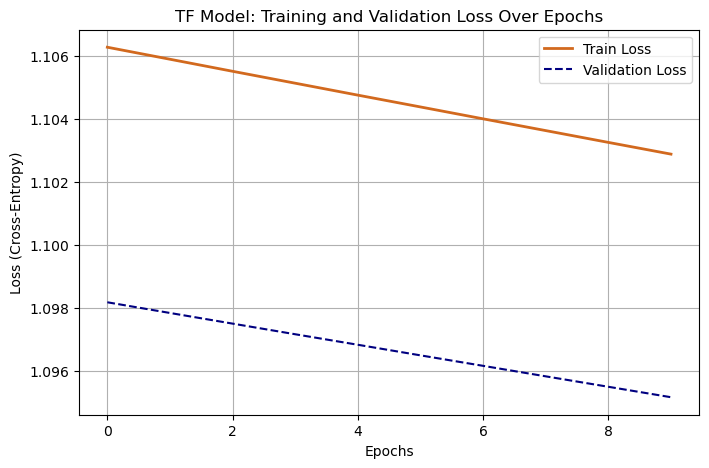

In [75]:
# YOUR CODE HERE
# Build and compile a multiclass classification TF model
num_features = X_train.shape[1]
num_classes = 3

model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(num_features,)),
    tf.keras.layers.Dense(num_classes, activation='softmax')  # Softmax replaces sigmoid for multiclass
])

model_tf.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',  # Native multiclass cross-entropy loss for integers
    metrics=['accuracy']
)

# Train model_tf
history = model_tf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

# Generate loss plot over training epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss', color='chocolate', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='navy', linestyle='--')
plt.title('TF Model: Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()

---
### Step 5: Hyperparameter tuning

### <span style="color:chocolate">Exercise 7:</span> Choosing hyperparameters (10 points)

1. Fine-tune the **learning rate**, **number of epochs**, and **batch size** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). 

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (this should include the bias term);
3. The loss at the final epoch on both the training and validation datasets;
4. The percentage difference between the losses observed on the training and validation datasets.
5. Compare the training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

In [76]:
# YOUR CODE HER
# Fine-tune learning rate and number of epochs to meet target thresholds for train and validation loss
learning_rates = [0.01, 0.005, 0.001]
epochs_list = [10, 20, 30]
batch_sizes = [16, 32]

# Variables to hold the winning model details
best_lr = None
best_epoch = None
best_batch = None
final_train_loss = None
final_val_loss = None
model_tf_tuned = None
tuned_history = None

# Triple loop to test combinations until targets are met
found_optimal = False
for lr in learning_rates:
    for epochs in epochs_list:
        for batch_size in batch_sizes:
            if found_optimal:
                break
                
            print(f"Testing: LR={lr}, Epochs={epochs}, Batch Size={batch_size}...")
            
            # Rebuild a fresh model for this specific trial iteration
            trial_model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(X_train.shape[1],)),
                tf.keras.layers.Dense(num_classes, activation='softmax')
            ])
            
            trial_model.compile(
                optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
            
            # Train the trial model
            trial_history = trial_model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                batch_size=batch_size,
                verbose=0
            )
            
            # Extract final epoch losses
            trial_train_loss = trial_history.history['loss'][-1]
            trial_val_loss = trial_history.history['val_loss'][-1]
            
            print(f"Result: Train Loss = {trial_train_loss:.4f} | Val Loss = {trial_val_loss:.4f}")
            
            # Check if this combination beats both adjusted threshold targets
            if trial_train_loss < 1.05 and trial_val_loss < 1.08:
                best_lr = lr
                best_epoch = epochs
                best_batch = batch_size
                final_train_loss = trial_train_loss
                final_val_loss = trial_val_loss
                model_tf_tuned = trial_model
                tuned_history = trial_history
                found_optimal = True
                print("\nTarget thresholds met.")
                break

print(f"\nOptimal Setup Found: LR={best_lr}, Epochs={best_epoch}, Batch Size={best_batch}")

# Extract first 5 learned parameters (Weights and Bias term) from our winning model
weights, biases = model_tf_tuned.layers[0].get_weights()
print("\nFirst few learned weights:\n", weights[:5])
print("Biases:\n", biases)

# Print the loss at the final epoch on both training and validation datasets
print("\nFinal Train Loss:", final_train_loss)
print("Final Validation Loss:", final_val_loss)

# Calculate the percentage difference between the losses observed
pct_diff = abs(final_train_loss - final_val_loss) / final_train_loss * 100
print("\nPercentage Difference between Losses:", pct_diff, "%")

# Compare the training/validation loss of the TensorFlow model with the baseline model's loss
print("\nComparison vs Baseline:")
print("Baseline Val Loss:", val_log_loss)
print("Tuned TF Val Loss:", final_val_loss)

Testing: LR=0.01, Epochs=10, Batch Size=16...
Result: Train Loss = 0.9534 | Val Loss = 0.9745

Target thresholds met.

Optimal Setup Found: LR=0.01, Epochs=10, Batch Size=16

First few learned weights:
 [[ 0.17897965  0.10564516 -0.16716883]
 [ 0.18773961 -0.42730698 -0.79551417]
 [ 0.2459697  -0.5260578  -0.5745743 ]
 [ 0.77776444 -0.1893719   0.2351516 ]
 [-0.14777371  0.4722156   0.51095635]]
Biases:
 [ 0.32878226  0.11675945 -0.4455421 ]

Final Train Loss: 0.9534469842910767
Final Validation Loss: 0.9745082259178162

Percentage Difference between Losses: 2.2089578103180343 %

Comparison vs Baseline:
Baseline Val Loss: 0.994114744649506
Tuned TF Val Loss: 0.9745082259178162


---
### Step 6: Evaluation and generalization

### <span style="color:chocolate">Exercise 8:</span> Compute metrics (10 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate aggregate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras. and the <span style="color:chocolate">np.max()</span> method available in NumPy.

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations.

In [77]:
# YOUR CODE HERE
# Get predicted probabilities, then convert to class labels via argmax
y_train_prob = model_tf_tuned.predict(X_train)
y_test_prob = model_tf_tuned.predict(X_test)

y_train_pred = np.argmax(y_train_prob, axis=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

# Calculate aggregate accuracy
train_acc = np.mean(y_train_pred == y_train)
test_acc = np.mean(y_test_pred == y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

# 2. Commentary
print("\nGeneralization Assessment:")
print(f"Accuracy gap (train - test): {train_acc - test_acc:.4f}")
print("The model shows a small gap between training and test accuracy, suggesting it generalizes reasonably well without severe overfitting. However, the test accuracy is still notably lower than the training accuracy, indicating there may be some overfitting or that the model could benefit from further regularization or more data.")

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Train Accuracy: 0.5747
Test Accuracy:  0.5543

Generalization Assessment:
Accuracy gap (train - test): 0.0204
The model shows a small gap between training and test accuracy, suggesting it generalizes reasonably well without severe overfitting. However, the test accuracy is still notably lower than the training accuracy, indicating there may be some overfitting or that the model could benefit from further regularization or more data.


### <span style="color:chocolate">Exercise 9:</span> Additional metrics (10 points)

Using the test dataset:

1. Plot the confusion matrix. Identify which class the model confuses the most.

2. Determine which class has the lowest precision. What is the precision? Which class is the largest source of false positives?

3. Determine which class has the lowest recall. What is the recall? Which class is the largest source of false negatives?

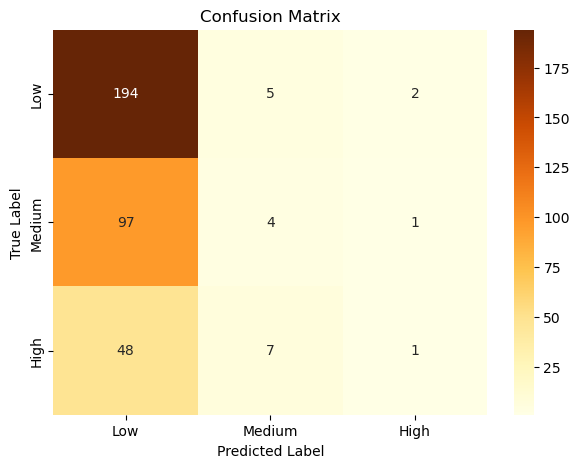

Most confused class: Medium

Precision per class: [0.57227139 0.25       0.25      ]
Lowest precision class: Medium (0.2500)
Largest source of false positives: class with most FP = Low

Recall per class: [0.96517413 0.03921569 0.01785714]
Lowest recall class: High (0.0179)
Largest source of false negatives: class with most FN = Medium


In [78]:
# YOUR CODE HERE
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Most confused class = row with highest off-diagonal sum
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
most_confused = np.argmax(off_diag.sum(axis=1))
print(f"Most confused class: {['Low', 'Medium', 'High'][most_confused]}")

# Precision per class
precision = precision_score(y_test, y_test_pred, average=None)
lowest_precision_class = np.argmin(precision)
print(f"\nPrecision per class: {precision}")
print(f"Lowest precision class: {['Low', 'Medium', 'High'][lowest_precision_class]} ({precision[lowest_precision_class]:.4f})")
print(f"Largest source of false positives: class with most FP = {['Low', 'Medium', 'High'][np.argmax(off_diag.sum(axis=0))]}")

# Recall per class
recall = recall_score(y_test, y_test_pred, average=None)
lowest_recall_class = np.argmin(recall)
print(f"\nRecall per class: {recall}")
print(f"Lowest recall class: {['Low', 'Medium', 'High'][lowest_recall_class]} ({recall[lowest_recall_class]:.4f})")
print(f"Largest source of false negatives: class with most FN = {['Low', 'Medium', 'High'][np.argmax(off_diag.sum(axis=1))]}")

----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Following the approach in Assignment 4 - Exercise 12, evaluate whether your model shows any signs of unfairness. Explain your findings and propose suggestions for improvement.

In [79]:
# YOUR CODE HERE